A live link to sankey html file:
https://emilie-lab.github.io/140.628.81_hw5_sankey/sankey.html

In [23]:
import requests as rq
import bs4
import pandas as pd

In [24]:
# Part 1
# Create a python file that webscrapes GDP by country and plots a stacked interactive bar plot using plotly. Stack countries within regions using the IMF numbers. Please include this in your ipython notebook and output your plot to an html file containing the plot.

In [25]:
#read the web page into data
url = 'https://en.wikipedia.org/wiki/List_of_countries_by_GDP_(nominal)'
page = rq.get(url, headers={"User-Agent": "Chrome"})
## print out the first 99 characters just to see what it looks like
page.text[0 : 99]

'<!DOCTYPE html>\n<html class="client-nojs vector-feature-language-in-header-enabled vector-feature-l'

In [26]:
#read the page into bs4
bs4page = bs4.BeautifulSoup(page.text, 'html.parser')
tables = bs4page.find_all('table',{'class':"wikitable"})

In [27]:
from io import StringIO
# Read the table from the StringIO object into pandas
dat = pd.read_html(StringIO(str(tables[0])))[0]

# delete World in Country/Territory
dat = dat[dat['Country/Territory'] != 'World']

# remove the [ ] in Country/Territory
dat['Country/Territory'] = dat['Country/Territory'].str.replace(r'\[.*?\]', '', regex=True)
#remove the ( ) in IMF (2026)[1]
dat['IMF (2026)[1]'] = dat['IMF (2026)[1]'].str.replace(r'\(.*?\)', '', regex=True)

#make sure IMF numbers are numeric
dat['IMF (2026)[1]'] = pd.to_numeric(dat['IMF (2026)[1]'], errors='coerce') #coerce makes invalid ones into NaN
#drop NAs in IMF (2026)[1]
dat = dat.dropna(subset=['IMF (2026)[1]'])

dat[:10]

,Country/Territory,IMF (2026)[1],World Bank (2024)[6],United Nations (2024)[7]
1,United States,32383920.0,28750956,29298000
2,China,20851593.0,18743803,18743802
3,Germany,5452858.0,4685593,4659929
4,Japan,4379253.0,4027598,4026211
5,United Kingdom,4264794.0,3686033,3685881
6,India,4153191.0,3909892,3952244
7,France,3596094.0,3160443,3160443
8,Italy,2738164.0,2380825,2380825
9,Russia,2656452.0,2173836,2173386
10,Brazil,2635912.0,2185822,2185822


In [28]:
import plotly.express as px
import numpy as np

In [29]:
#For the following plotting steps, I googled "convert country to continent in python". 
#The AI overview suggested me to use "pycountry-convert" or "country-converter". I ended up using "country-converter".


#Ref: country-converter. PyPI. Published October 22, 2025. Accessed May 4, 2026. https://pypi.org/project/country-converter/

In [30]:
!pip install country_converter
import country_converter as coco


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: C:\Users\emily\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [31]:
# Pass Country/Territory column to the converter, and create a new column in your called Continent
dat['Continent'] = coco.convert(names=dat['Country/Territory'], to='continent')

print(dat.head())

  Country/Territory  IMF (2026)[1] World Bank (2024)[6]  \
1     United States     32383920.0             28750956   
2             China     20851593.0             18743803   
3           Germany      5452858.0              4685593   
4             Japan      4379253.0              4027598   
5    United Kingdom      4264794.0              3686033   

  United Nations (2024)[7] Continent  
1                 29298000   America  
2                 18743802      Asia  
3                  4659929    Europe  
4                  4026211      Asia  
5                  3685881    Europe  


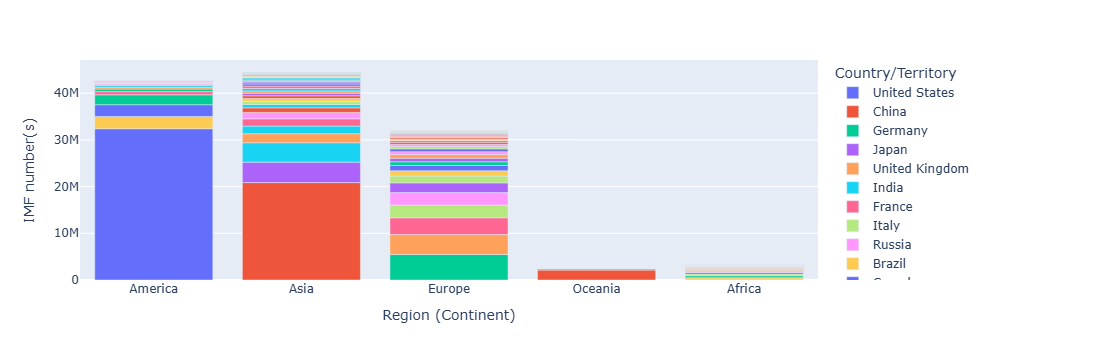

In [32]:
#create the stacked bar chart using plotly
fig1 = px.bar(dat,
             x = "Continent",
             y = "IMF (2026)[1]",
             color = "Country/Territory",
             labels={
                   "Continent": "Region (Continent)",
                   "IMF (2026)[1]": "IMF number(s)"
                    })


fig1.show()

In [33]:
# Part2
#Look at the chapter on interactive graphics and, specifically, the code to display a subject's MRICloud data as a sunburst plot. Do the following. Display this subject's data as a Sankey diagram. Display as many levels as you can (at least 3) for Type = 1, starting from the intracranial volume.

In [34]:
## load in the hierarchy information
url = "https://raw.githubusercontent.com/bcaffo/MRIcloudT1volumetrics/master/inst/extdata/multilevel_lookup_table.txt"
multilevel_lookup = pd.read_csv(url, sep = "\t").drop(['Level5'], axis = 1)
multilevel_lookup = multilevel_lookup.rename(columns = {
    "modify"   : "roi",
    "modify.1" : "level4",
    "modify.2" : "level3",
    "modify.3" : "level2",
    "modify.4" : "level1"})
multilevel_lookup = multilevel_lookup[['roi', 'level3', 'level2', 'level1']]
multilevel_lookup.head()

,roi,level3,level2,level1
0,SFG_L,Frontal_L,CerebralCortex_L,Telencephalon_L
1,SFG_R,Frontal_R,CerebralCortex_R,Telencephalon_R
2,SFG_PFC_L,Frontal_L,CerebralCortex_L,Telencephalon_L
3,SFG_PFC_R,Frontal_R,CerebralCortex_R,Telencephalon_R
4,SFG_pole_L,Frontal_L,CerebralCortex_L,Telencephalon_L


In [35]:
## Now load in the subject data
id = 127
subjectData = pd.read_csv("https://raw.githubusercontent.com/smart-stats/ds4bio_book/main/book/assetts/kirby21AllLevels.csv")
subjectData = subjectData.loc[(subjectData.type == 1) & (subjectData.level == 5) & (subjectData.id == id)]
subjectData = subjectData[['roi', 'volume']]
## Merge the subject data with the multilevel data
subjectData = pd.merge(subjectData, multilevel_lookup, on = "roi")
subjectData = subjectData.assign(icv = "ICV")


subjectData = subjectData.assign(comp = subjectData.volume / np.sum(subjectData.volume))
subjectData.head()

,roi,volume,level3,level2,level1,icv,comp
0,SFG_L,12926,Frontal_L,CerebralCortex_L,Telencephalon_L,ICV,0.009350
1,SFG_R,10050,Frontal_R,CerebralCortex_R,Telencephalon_R,ICV,0.007270
2,SFG_PFC_L,12783,Frontal_L,CerebralCortex_L,Telencephalon_L,ICV,0.009247
3,SFG_PFC_R,11507,Frontal_R,CerebralCortex_R,Telencephalon_R,ICV,0.008324
4,SFG_pole_L,3078,Frontal_L,CerebralCortex_L,Telencephalon_L,ICV,0.002227


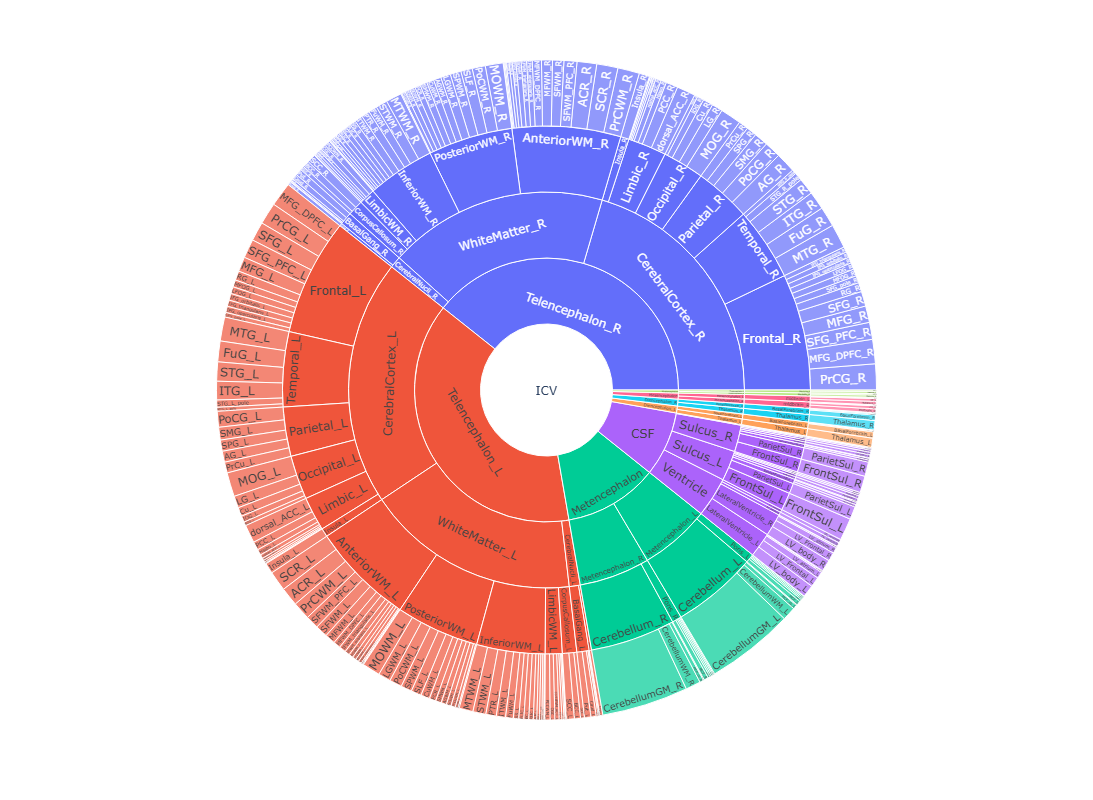

In [36]:
fig = px.sunburst(subjectData, path=['icv', 'level1', 'level2', 'level3', 'roi'],
                  values='comp', width=800, height=800)
fig.show()

In [37]:
import plotly.graph_objects as go

In [38]:
# Display 'icv', 'level1', 'level2', 'level3'

# create empty lists
sources = []
targets = []
values = []

# from ICV to Level 1
# sum up the volumes
grouped = subjectData.groupby(['icv', 'level1'], as_index=False)['comp'].sum()

print(grouped[:10])

#add to empty lists
sources.extend(grouped['icv'].tolist())
targets.extend(grouped['level1'].tolist())
values.extend(grouped['comp'].tolist())

   icv           level1      comp
0  ICV              CSF  0.079417
1  ICV   Diencephalon_L  0.008548
2  ICV   Diencephalon_R  0.008362
3  ICV    Mesencephalon  0.007430
4  ICV    Metencephalon  0.115313
5  ICV   Myelencephalon  0.003599
6  ICV  Telencephalon_L  0.384220
7  ICV  Telencephalon_R  0.393111


In [39]:
# from Level 1 to Level 2
# sum up the volumes
grouped = subjectData.groupby(['level1', 'level2'], as_index=False)['comp'].sum()

#add to lists
sources.extend(grouped['level1'].tolist())
targets.extend(grouped['level2'].tolist())
values.extend(grouped['comp'].tolist())


# from Level 2 to Level 3
# sum up the volumes
grouped = subjectData.groupby(['level2', 'level3'], as_index=False)['comp'].sum()

print(grouped[:10])

#add to lists
sources.extend(grouped['level2'].tolist())
targets.extend(grouped['level3'].tolist())
values.extend(grouped['comp'].tolist())

             level2            level3      comp
0  BasalForebrain_L  BasalForebrain_L  0.003960
1  BasalForebrain_R  BasalForebrain_R  0.003753
2  CerebralCortex_L         Frontal_L  0.071375
3  CerebralCortex_L          Insula_L  0.005238
4  CerebralCortex_L          Limbic_L  0.020831
5  CerebralCortex_L       Occipital_L  0.026950
6  CerebralCortex_L        Parietal_L  0.030148
7  CerebralCortex_L        Temporal_L  0.045819
8  CerebralCortex_R         Frontal_R  0.071329
9  CerebralCortex_R          Insula_R  0.005123


In [40]:
print(sources[:10])
print(targets[:10])

['ICV', 'ICV', 'ICV', 'ICV', 'ICV', 'ICV', 'ICV', 'ICV', 'CSF', 'CSF']
['CSF', 'Diencephalon_L', 'Diencephalon_R', 'Mesencephalon', 'Metencephalon', 'Myelencephalon', 'Telencephalon_L', 'Telencephalon_R', 'Sulcus_L', 'Sulcus_R']


In [41]:
# Create a list of unique labels from sources and targets
label_list = list(set(sources + targets))

print(label_list[:10])

# Create a dictionary of nodes
node_mapping = {}

#for every label(node) in the label_list, give it an ordered number
for i, node in enumerate(label_list):
  node_mapping[node] = i

print(node_mapping)

['Temporal_R', 'TempSul_R', 'BasalForebrain_R', 'Frontal_R', 'Mesencephalon', 'Limbic_R', 'Telencephalon_R', 'CentralSul_L', 'CerebralNucli_L', 'Insula_R']
{'Temporal_R': 0, 'TempSul_R': 1, 'BasalForebrain_R': 2, 'Frontal_R': 3, 'Mesencephalon': 4, 'Limbic_R': 5, 'Telencephalon_R': 6, 'CentralSul_L': 7, 'CerebralNucli_L': 8, 'Insula_R': 9, 'PosteriorWM_L': 10, 'ParietSul_R': 11, 'Occipital_L': 12, 'Cerebellum_R': 13, 'Medulla_R': 14, 'Insula_L': 15, 'Ventricle': 16, 'CerebralCortex_R': 17, 'CerebralCortex_L': 18, 'CinguSul_R': 19, 'Temporal_L': 20, 'FrontSul_L': 21, 'CerebralNucli_R': 22, 'Myelencephalon_L': 23, 'III_ventricle': 24, 'midbrain_R': 25, 'IV_ventricle': 26, 'Metencephalon_R': 27, 'Thalamus_L': 28, 'OcciptSul_R': 29, 'SylvianFissureExt_L': 30, 'Telencephalon_L': 31, 'midbrain_L': 32, 'CorpusCallosum_R': 33, 'CorpusCallosum_L': 34, 'OcciptSul_L': 35, 'TempSul_L': 36, 'PosteriorWM_R': 37, 'Ventricle ': 38, 'Thalamus_R': 39, 'Myelencephalon': 40, 'WhiteMatter_L': 41, 'BasalFor

In [42]:
#create empty list for the source numbers
source_num = []

#for sou in sources(list), give the text a number
for sou in sources:
  number = node_mapping[sou] #look up its number
  source_num.append(number) #append to the new list (source_num)


#create empty list for the target numbers
target_num = []

#for target in targets(list), give the text a number
for tar in targets:
  number = node_mapping[tar] #look up its number
  target_num.append(number) #append to the new list (target_num)

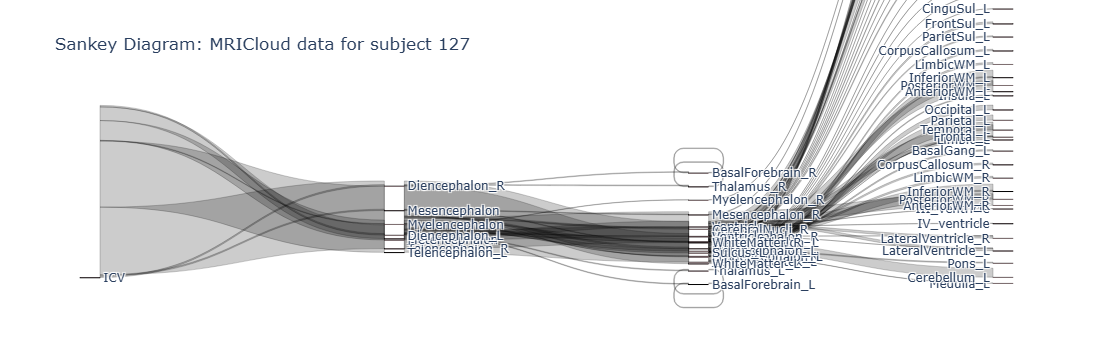

In [43]:
# create the plot
fig2 = go.Figure(data=[go.Sankey(
    node = dict(
      pad = 15,
      thickness = 20,
      line = dict(color = "black", width = 0.5),
      label = label_list,
      color = "pink"
    ),
    link = dict(
      source = source_num, 
      target = target_num,
      value = values
  ))])

fig2.update_layout(title_text="Sankey Diagram: MRICloud data for subject 127", font_size=12)

fig2.show()

In [46]:
# use write_html to make my interactive plots into two html files
# ref: Interactive. Plotly.com. Published 2026. Accessed May 6, 2026. https://plotly.com/python/interactive-html-export/

In [47]:
fig1.write_html("C:/Users/emily/stacked_bar.html")
fig2.write_html("C:/Users/emily/sankey.html")